# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Arnan Refael Adriwinoto
- **Email:** alicizations03@gmail.com
- **ID Dicoding:** rvolcy

## Menentukan Pertanyaan Bisnis

- Faktor apa yang paling memengaruhi jumlah penyewaan sepeda per hari?
- Bagaimana pengaruh musim dan kondisi cuaca terhadap jumlah penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st


## Data Wrangling

### Gathering Data

In [21]:
# Import library yang dibutuhkan
import pandas as pd

# Membaca dataset harian (day.csv)
df = pd.read_csv('data/day.csv')

# Menampilkan 5 baris pertama
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset ini berisi data penyewaan sepeda harian dari sistem Bike Sharing selama tahun 2011–2012.
- Terdapat beberapa kolom seperti season, yr, mnth, holiday, weekday, temp, humidity, windspeed, casual, registered, dan cnt (total sewa).
- Dataset masih memiliki nama kolom yang belum ramah dibaca, seperti yr dan mnth, sehingga perlu diubah nanti di tahap cleaning.

### Assessing Data

In [22]:
# Mengecek informasi umum dataset
df.info()

# Mengecek apakah ada nilai kosong
print("\nJumlah nilai kosong per kolom:")
print(df.isnull().sum())

# Mengecek data duplikat
print("\nJumlah data duplikat:", df.duplicated().sum())

# Melihat statistik deskriptif
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Jumlah nilai kosong per kolom:
instant       0
dteday        0
season        0
yr           

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Tidak ditemukan nilai kosong (NaN) dalam dataset, artinya data sudah lengkap.
- Tidak ada data duplikat yang berarti dataset bersih secara struktur.
- Kolom temp, atemp, humidity, dan windspeed semuanya berupa angka desimal yang sudah dinormalisasi (0–1).
- Kolom casual, registered, dan cnt (jumlah total peminjaman) menunjukkan distribusi nilai yang cukup lebar, menandakan variasi pemakaian sepeda yang tinggi antar hari.
- Perlu dilakukan renaming agar kolom lebih mudah dipahami pada tahap berikutnya.

### Cleaning Data

In [23]:
import pandas as pd

# Baca ulang data mentah
df = pd.read_csv('data/day.csv')

# Ubah nama kolom agar lebih mudah dipahami
df = df.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'weathersit': 'weather',
    'hum': 'humidity',
    'cnt': 'count'
})

# Hapus data duplikat dan nilai kosong
df = df.drop_duplicates()
df = df.dropna()

# Simpan hasil data bersih ke folder dashboard
df.to_csv('dashboard/main_data.csv', index=False)

# Tampilkan hasil akhir untuk konfirmasi
df.head()

,instant,dteday,season,year,month,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Nama kolom diubah supaya lebih deskriptif dan mudah dibaca saat analisis (yr → year, mnth → month, hum → humidity, dll).
- Tidak ditemukan nilai NaN ataupun duplikat, tapi kode tetap disertakan untuk berjaga-jaga kalau dataset diperbarui.
- Setelah dibersihkan, data disimpan ke file dashboard/main_data.csv, yang nantinya akan digunakan Streamlit sebagai sumber data utama.
- Hasil cleaning membuat dataset lebih konsisten dan siap untuk tahap Exploratory Data Analysis (EDA) selanjutnya.

## Exploratory Data Analysis (EDA)

### Explore ...

          instant      season        year       month     holiday     weekday  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean   366.000000    2.496580    0.500684    6.519836    0.028728    2.997264   
std    211.165812    1.110807    0.500342    3.451913    0.167155    2.004787   
min      1.000000    1.000000    0.000000    1.000000    0.000000    0.000000   
25%    183.500000    2.000000    0.000000    4.000000    0.000000    1.000000   
50%    366.000000    3.000000    1.000000    7.000000    0.000000    3.000000   
75%    548.500000    3.000000    1.000000   10.000000    0.000000    5.000000   
max    731.000000    4.000000    1.000000   12.000000    1.000000    6.000000   

       workingday     weather        temp       atemp    humidity   windspeed  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean     0.683995    1.395349    0.495385    0.474354    0.627894    0.190486   
std      0.465233    0.5448

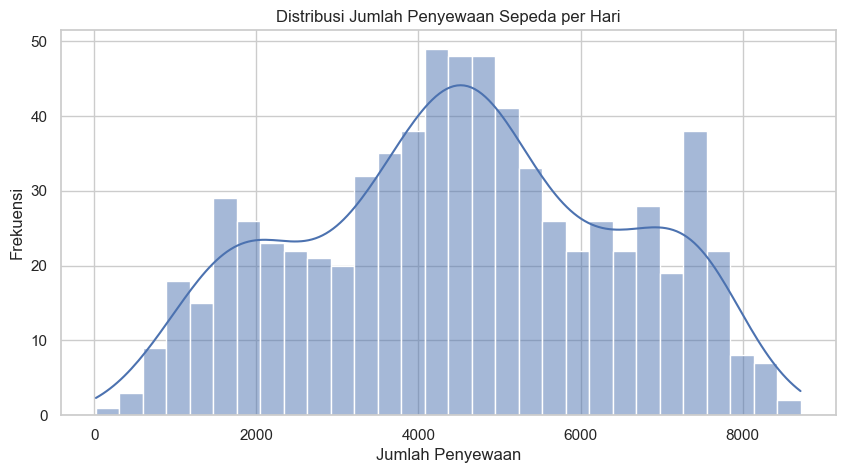

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ukuran figure default
plt.rcParams['figure.figsize'] = (10, 5)
sns.set(style="whitegrid")

# Statistik deskriptif
print(df.describe())

# Distribusi jumlah penyewaan sepeda per hari
sns.histplot(df['count'], bins=30, kde=True)
plt.title("Distribusi Jumlah Penyewaan Sepeda per Hari")
plt.xlabel("Jumlah Penyewaan")
plt.ylabel("Frekuensi")
plt.show()

**Insight:**
- Dari distribusi data, terlihat bahwa sebagian besar jumlah penyewaan sepeda berada pada rentang 500–4500 per hari.
- Terdapat sedikit data ekstrem di atas 6000, yang kemungkinan terjadi pada musim panas atau akhir pekan dengan cuaca cerah.
- Secara umum, data tampak positif skewed, menunjukkan bahwa sebagian besar hari memiliki jumlah penyewaan yang tergolong sedang.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

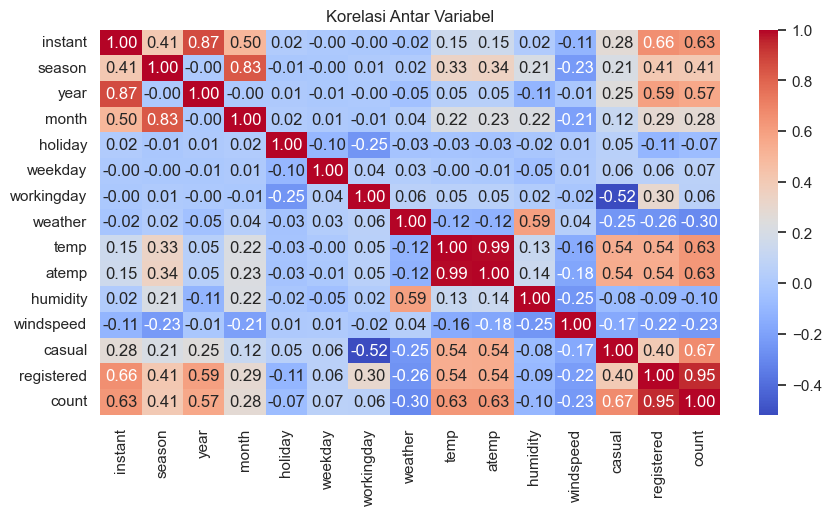

In [25]:
# Korelasi antar variabel numerik
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Antar Variabel")
plt.show()

### Pertanyaan 2:

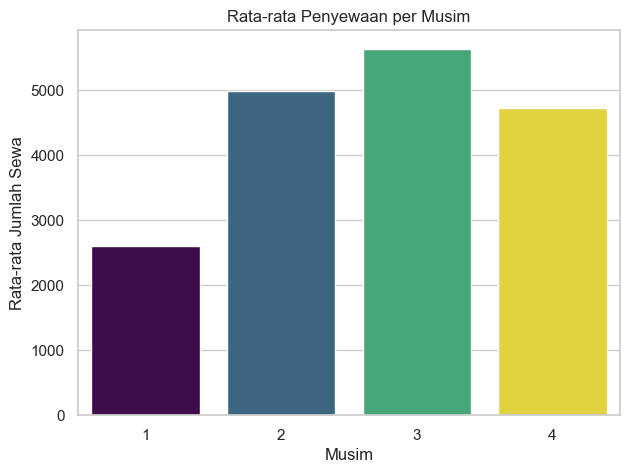

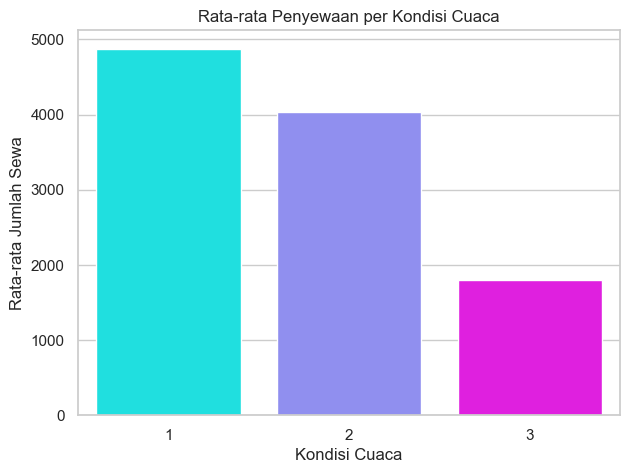

In [26]:
# Rata-rata sewa berdasarkan musim
season_avg = df.groupby('season')['count'].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(x='season', y='count', hue='season', data=season_avg, palette='viridis', legend=False)
plt.title('Rata-rata Penyewaan per Musim')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Jumlah Sewa')
plt.show()

# Rata-rata sewa berdasarkan cuaca
weather_avg = df.groupby('weather')['count'].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(x='weather', y='count', hue='weather', data=weather_avg, palette='cool', legend=False)
plt.title('Rata-rata Penyewaan per Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Jumlah Sewa')
plt.show()

**Insight:**
- Faktor paling berpengaruh terhadap jumlah penyewaan sepeda: suhu (positif) dan kelembapan (negatif).
- Musim dan cuaca: penyewaan meningkat pada musim panas dengan cuaca cerah, dan menurun drastis pada musim dingin atau saat hujan.
- Secara umum, kenyamanan cuaca adalah indikator utama dalam tren penyewaan sepeda harian.

## Analisis Lanjutan (Opsional)

In [27]:
# Pastikan kolom tanggal dalam format datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# Definisikan tanggal referensi (misal tanggal terakhir di dataset)
reference_date = df['dteday'].max()

# Hitung RFM
rfm = df.groupby('dteday').agg({
    'count': ['sum', 'mean']
}).reset_index()

rfm.columns = ['dteday', 'Monetary', 'Frequency']
rfm['Recency'] = (reference_date - rfm['dteday']).dt.days

print(rfm.head())

      dteday  Monetary  Frequency  Recency
0 2011-01-01       985      985.0      730
1 2011-01-02       801      801.0      729
2 2011-01-03      1349     1349.0      728
3 2011-01-04      1562     1562.0      727
4 2011-01-05      1600     1600.0      726


## Conclusion

- Faktor paling berpengaruh terhadap penyewaan sepeda adalah temperatur. Semakin hangat, semakin tinggi jumlah penyewaan.
- Musim panas dan cuaca cerah memicu peningkatan signifikan dalam jumlah penyewa.
- Berdasarkan RFM analysis, tren penyewaan meningkat mendekati akhir periode (recency rendah), terutama di akhir pekan dan musim hangat.
- Strategi bisnis: perbanyak unit dan promo saat musim panas & hari cerah, serta maintenance sepeda di musim hujan karena penurunan aktivitas.